tutaj koncentrujemy się głównie na analizie jedno- i wielowymiarowej wybranych zmiennych, ale także część analiz możemy podciągnąć pod ogólną analize cen (można to potraktować jako motywacja do konstrukcji zmiennych w poprzednim skrypcie)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import math
import folium

import rasterio
from rasterio.transform import rowcol
from rasterio.merge import merge
from rasterio.mask import mask
from pyproj import Transformer

import osmium

from sklearn.neighbors import BallTree
from tqdm import tqdm
import time

from sklearn.cluster import DBSCAN

from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from sklearn.preprocessing import RobustScaler
from branca.colormap import linear

from ydata_profiling import ProfileReport

In [2]:
# DEFINICJE #

# MAPY #
france_regions_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/regions.geojson" 
france_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements-version-simplifiee.geojson" 

# TRZCIONKA NA WYKRESACH #
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5})

0. PRÓBKOWANIE

In [3]:
data = pd.read_csv("D:\\nieruchomosci_ostateczne\\samples\\sample_enhanced_final.txt", low_memory = False)

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)

ids_houses = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\houses_transaction_ids.txt", dtype=str)
ids_apartments = np.loadtxt("D:\\nieruchomosci_ostateczne\\samples\\apartments_transaction_ids.txt", dtype=str)

all_ids = set(ids1) | set(ids2) | set(ids3)
apartment_ids = set(ids1) | set(ids2) 

sample_one_apartment = data[data.transaction_id.isin(ids1)]
sample_one_apartment_one_outbuilding = data[data.transaction_id.isin(ids2)]
sample_one_house = data[data.transaction_id.isin(ids3)]
sample_one_apartment_paris = sample_one_apartment[sample_one_apartment.department_code == '75']

# dodać takie overall próbki + w targecie mapka tej ceny

In [4]:
CHOICE = 1

if CHOICE == 1:
    sample = sample_one_apartment
elif CHOICE == 2:
    sample = sample_one_apartment_one_outbuilding
elif CHOICE == 3:
    sample = sample_one_house
elif CHOICE == 4:
    sample = sample_one_apartment_paris

elif CHOICE == -1:
    sample = data[data.transaction_id.isin(ids_houses)]
elif CHOICE == -2:
    sample = data[data.transaction_id.isin(ids_apartments)]

ydata-profiling

In [6]:

subset = sample[['transaction_id', 'number_of_rooms', 'built_surface', 'longitude', 'latitude', 'price_m_2']]
profile = ProfileReport(subset, title="Profiling Report")

In [7]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:13<00:00,  2.17s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

tool do outlierów

count    982438.000000
mean         50.136910
std          28.028044
min           1.000000
25%          30.000000
50%          45.000000
75%          65.000000
max        1400.000000
Name: full_built_surface, dtype: float64

0.90     82.0
0.95     97.0
0.98    120.0
0.99    141.0
Name: full_built_surface, dtype: float64

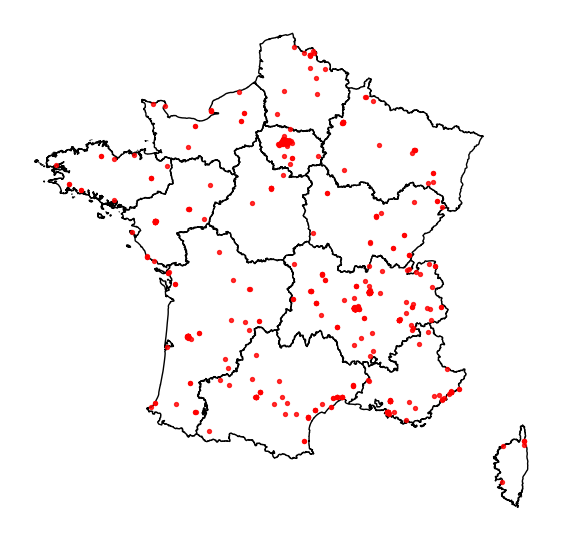

In [40]:
variable = 'full_built_surface'
quant = 0.999

display(sample[variable].describe())
display(sample[variable].quantile([0.9, 0.95, 0.98, 0.99]))

map = gpd.read_file(france_regions_map_url)

subset = sample[sample[variable] > sample[variable].quantile(quant)]
points = gpd.GeoDataFrame(subset, geometry=gpd.points_from_xy(subset.longitude, subset.latitude), crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(7, 7))
map.plot(ax=ax, facecolor="white", edgecolor="black")
points.plot(ax=ax, color="red", markersize=8, alpha=0.8)

ax.set_axis_off()
plt.show()

1. ANALIZA TARGETU

In [17]:
# sample = sample.copy()
# sample[["price_m_2", "price_m_2_adj"]] = sample[["price_m_2", "price_m_2_adj"]].replace([np.inf, -np.inf], np.nan)
# sample = sample.dropna(subset=["price_m_2", "price_m_2_adj"])

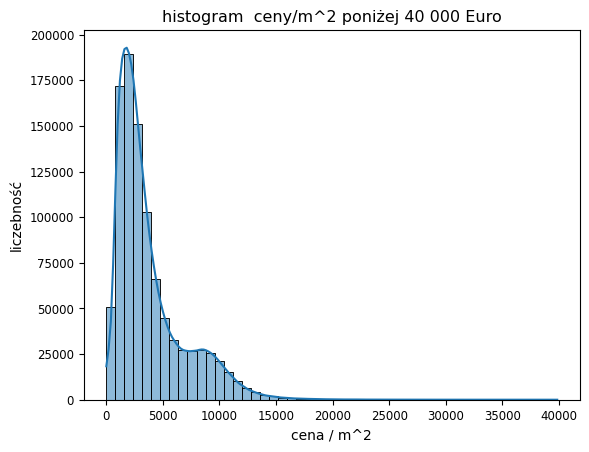

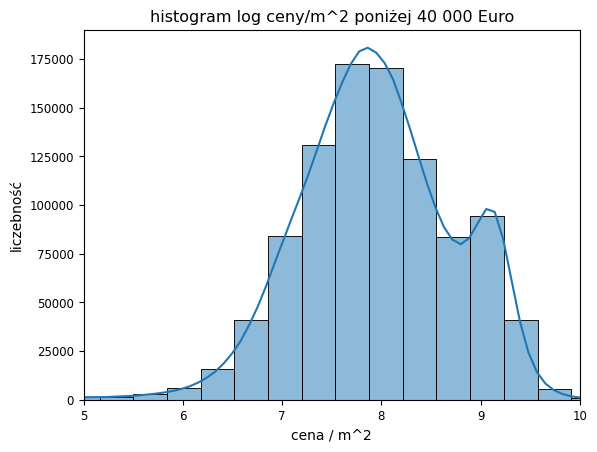

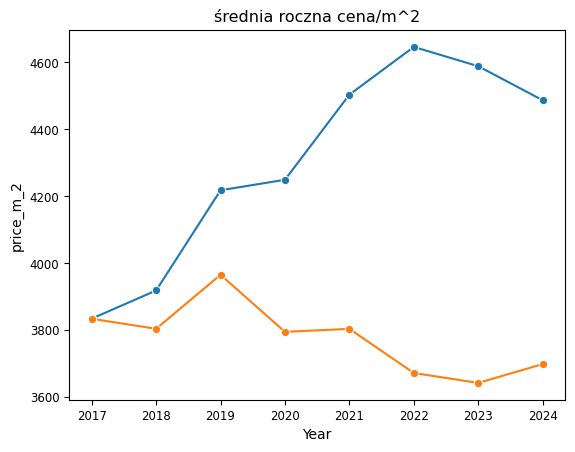

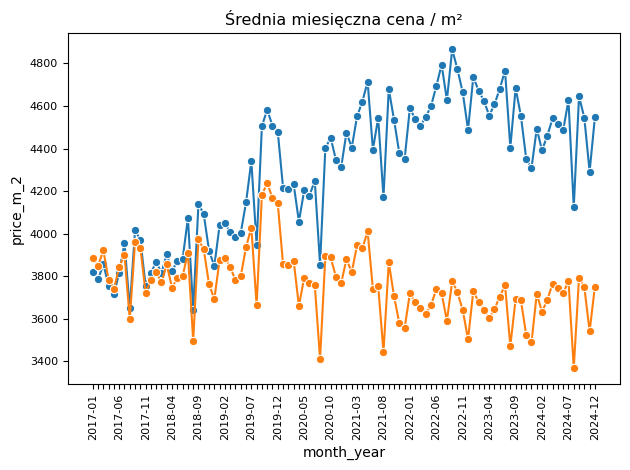

In [5]:
target = sample['price_m_2']
target_adj = sample['price_m_2_adj']

target = target[target < 40_000]  
target_adj = target_adj[target_adj < 40_000]

sns.histplot(target_adj, bins=50, kde=True)
plt.title("histogram  ceny/m^2 poniżej 40 000 Euro")
plt.xlabel("cena / m^2")
plt.ylabel("liczebność")
plt.show()

target_adj_log = np.log(target_adj)

sns.histplot(target_adj_log, bins=50, kde=True)
plt.title("histogram log ceny/m^2 poniżej 40 000 Euro")
plt.xlabel("cena / m^2")
plt.xlim((5,10))
plt.ylabel("liczebność")
plt.show()

avg_per_year = sample.groupby(sample.year).price_m_2.mean().reset_index(name = 'price_m_2')
avg_per_year['Year'] = avg_per_year.year.astype(str)
avg_per_year = avg_per_year[['Year', 'price_m_2']]

avg_per_year_adj = sample.groupby(sample.year).price_m_2_adj.mean().reset_index(name = 'price_m_2_adj')
avg_per_year_adj['Year'] = avg_per_year_adj.year.astype(str)
avg_per_year_adj = avg_per_year_adj[['Year', 'price_m_2_adj']]


sns.lineplot(data = avg_per_year, x="Year", y="price_m_2", marker = "o")
sns.lineplot(data = avg_per_year_adj, x="Year", y="price_m_2_adj", marker = "o")
plt.title("średnia roczna cena/m^2")
plt.show()


avg_per_month = sample.groupby(sample.month_year).price_m_2.mean().reset_index(name='price_m_2')
avg_per_year['month'] = avg_per_month.month_year.astype(str)

avg_per_month_adj = sample.groupby(sample.month_year).price_m_2_adj.mean().reset_index(name='price_m_2_adj')
avg_per_year_adj['month'] = avg_per_month.month_year.astype(str)

ax = sns.lineplot(data=avg_per_month, x="month_year", y="price_m_2", marker="o")
sns.lineplot(data=avg_per_month_adj, x="month_year", y="price_m_2_adj", marker="o", ax=ax)

plt.title("Średnia miesięczna cena / m²")
plt.xticks(rotation=90)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

cena za metr kwadratowy w podziale na departamenty/regiony

c:\Users\jpiec\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


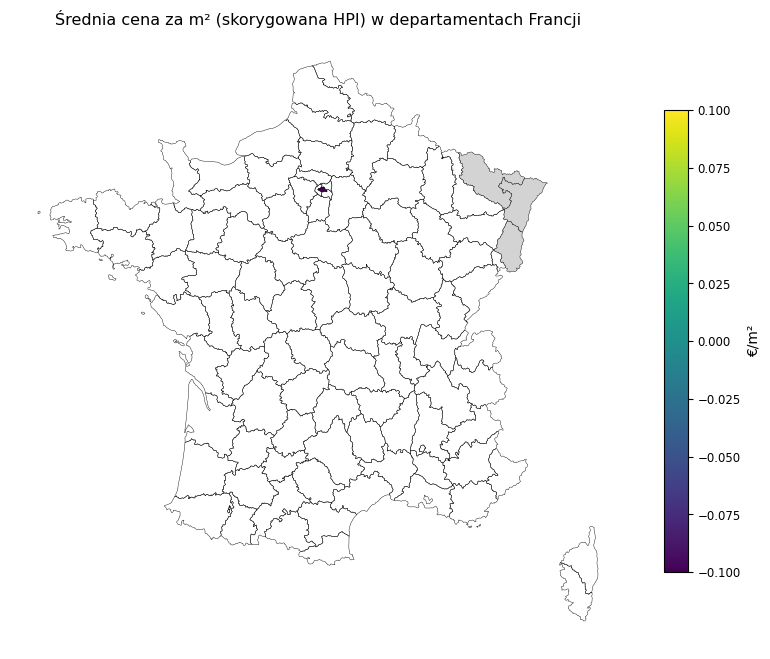

In [15]:
sample_department = sample.groupby('department_code').price_m_2_adj.mean().reset_index(name='avg_price_m_2_adj')

fr_map = gpd.read_file(france_departments_map_url)
fr_map = fr_map.merge(sample_department, how = 'left', left_on='code', right_on='department_code')

fig, ax = plt.subplots(figsize=(8, 8))
fr_map.plot(column="avg_price_m_2_adj", ax=ax, cmap="viridis", legend=True,  missing_kwds={"color": "lightgrey", "label": "brak danych"}, 
        edgecolor="black", linewidth=0.3,  legend_kwds={"shrink": 0.6, "label": "€/m²"})

ax.set_title("Średnia cena za m² (skorygowana HPI) w departamentach Francji")
ax.axis("off")

plt.tight_layout()
plt.show()

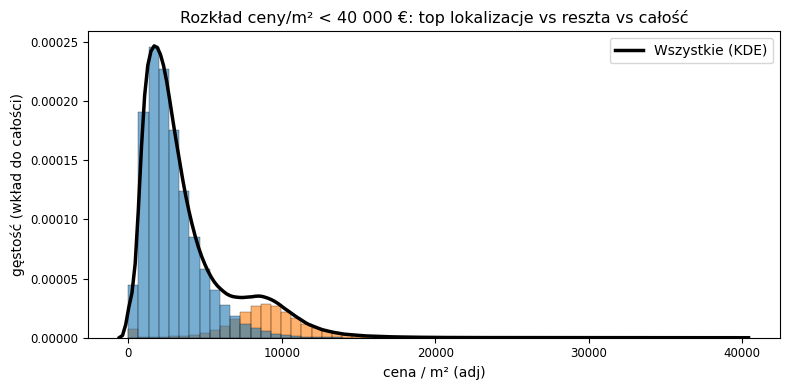

In [7]:
# PRZYKŁAD: dlaczego rozkład 2-modalny dla mieszań ? Chodzi o Paryż I np. miasta na Lazurowym Wybrzeżu, gdzie ceny są wyższe #

coastal_communes_06 = ["06088", "06157", "06123", "06027", "06149", "06030", "06155", "06159", "06152"]

sample = sample.copy()
sample[["price_m_2", "price_m_2_adj"]] = sample[["price_m_2", "price_m_2_adj"]].replace([np.inf, -np.inf], np.nan)
sample = sample.dropna(subset=["price_m_2", "price_m_2_adj"])

df = sample[sample.price_m_2_adj < 40_000].copy()
df_rich_cities  = df[(df.department_code == '75') | (df.postal_code.isin(coastal_communes_06))]
df_rest = df[~(df.department_code == '75') | (df.postal_code.isin(coastal_communes_06))]

df_plot = df.copy()
df_plot["group"] = "Reszta Francji"
df_plot.loc[df_plot.index.isin(df_rich_cities.index), "group"] = "Paryż + inne drogie miasta"

plt.figure(figsize=(8,4))

sns.histplot(data=df_plot, x="price_m_2_adj", hue="group", bins=60, stat="density", common_norm=True, multiple="layer", alpha=0.6, edgecolor="black", linewidth=0.2)
sns.kdeplot(data=df_plot, x="price_m_2_adj", color="black", lw=2.5, label="Wszystkie (KDE)")

plt.title("Rozkład ceny/m² < 40 000 €: top lokalizacje vs reszta vs całość")
plt.xlabel("cena / m² (adj)")
plt.ylabel("gęstość (wkład do całości)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# PRZYKŁAD: boxplot targetu w próbkach
#TODO

2. ANALIZA `number_of_rooms` i `built_surface`

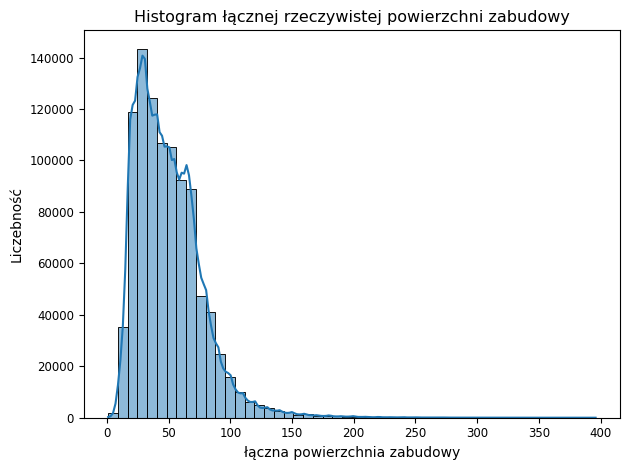

In [38]:
sns.histplot(data=sample[sample.full_built_surface < 400], x="full_built_surface", bins=50, kde=True)

plt.title("Histogram łącznej rzeczywistej powierzchni zabudowy")
plt.xlabel("łączna powierzchnia zabudowy")
plt.ylabel("Liczebność")
plt.tight_layout()
plt.show()

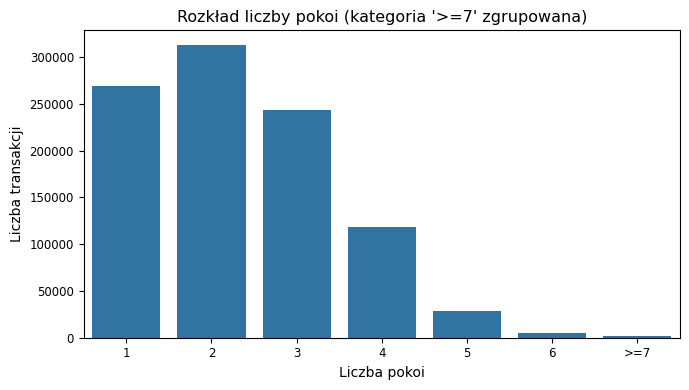

In [36]:
rooms = pd.to_numeric(sample["number_of_rooms"], errors="coerce").dropna()
rooms_cat = rooms.clip(upper=7).replace({7: ">=7"})
counts = rooms_cat.value_counts()
order = [1, 2, 3, 4, 5, 6, ">=7"]
subset = counts.reindex(order, fill_value=0).reset_index()
subset.columns = ["number_of_rooms", "freq"]

plt.figure(figsize=(7, 4))
sns.barplot(data=subset, x="number_of_rooms", y="freq", order=order)
plt.title("Rozkład liczby pokoi (kategoria '>=7' zgrupowana)")
plt.xlabel("Liczba pokoi")
plt.ylabel("Liczba transakcji")
plt.tight_layout()
plt.show()

<Axes: xlabel='full_built_surface', ylabel='price_m_2'>

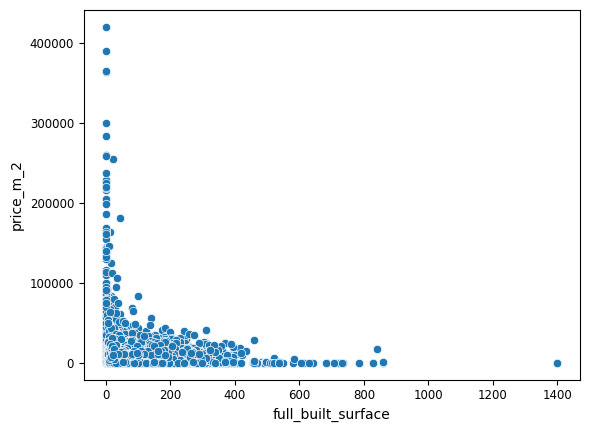

In [57]:
#sns.scatterplot(x='number_of_rooms', y='full_built_surface', data=sample)

sns.scatterplot(x='full_built_surface', y='price_m_2', data=sample)

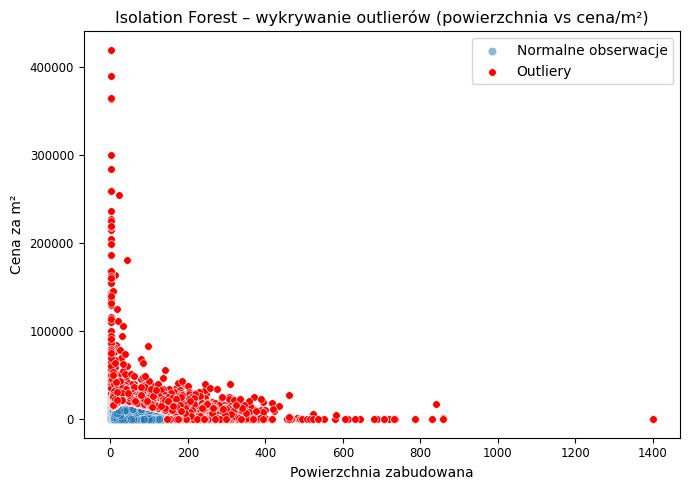

In [60]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sample[["full_built_surface", "price_m_2"]].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,   # ~2% outlierów (możesz zmienić na 0.01–0.05)
    random_state=42
)

df["outlier_flag"] = iso.fit_predict(df)   # -1 = outlier, 1 = normal

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df[df["outlier_flag"] == 1],
    x="full_built_surface",
    y="price_m_2",
    alpha=0.5,
    label="Normalne obserwacje"
)

sns.scatterplot(
    data=df[df["outlier_flag"] == -1],
    x="full_built_surface",
    y="price_m_2",
    color="red",
    s=30,
    label="Outliery"
)

plt.title("Isolation Forest – wykrywanie outlierów (powierzchnia vs cena/m²)")
plt.xlabel("Powierzchnia zabudowana")
plt.ylabel("Cena za m²")
plt.legend()
plt.tight_layout()
plt.show()


In [59]:
def get_outliers(cont):
    iso = IsolationForest(n_estimators=300, contamination=cont, random_state=42)
    flags = iso.fit_predict(df[["full_built_surface", "price_m_2"]])
    return set(df.index[flags == -1])

out_1 = get_outliers(0.01)
out_2 = get_outliers(0.02)
out_3 = get_outliers(0.03)

print("Overlap 1% vs 2%:", len(out_1 & out_2) / max(1, len(out_1)))
print("Overlap 2% vs 3%:", len(out_2 & out_3) / max(1, len(out_2)))


Overlap 1% vs 2%: 1.0
Overlap 2% vs 3%: 1.0


3. REPREZENTATYWNOŚĆ DANYCH

stabilność próbki w czasie

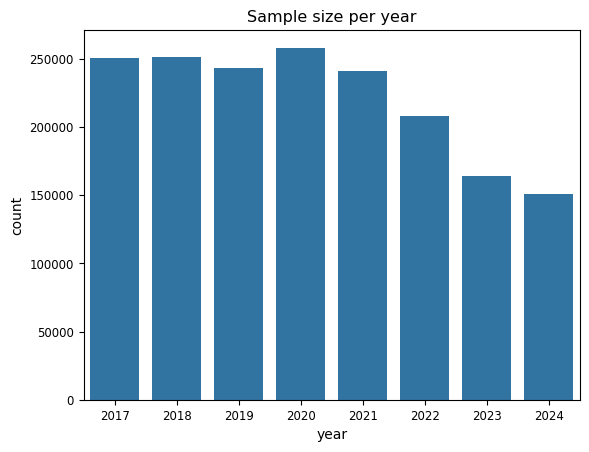

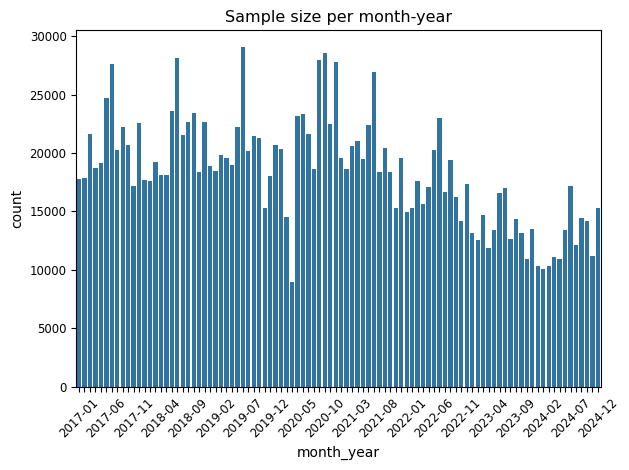

In [10]:
size_per_year = sample.groupby('year').size().reset_index(name="count")

sns.barplot(data = size_per_year, x="year", y="count")
plt.title("Sample size per year")
plt.show()


size_per_month = sample.groupby('month_year').size().reset_index(name='count')
size_per_month['month_year'] = size_per_month.month_year.astype(str)

ax = sns.barplot(data=size_per_month, x="month_year", y="count")

for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

plt.title('Sample size per month-year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

stabilność w przestrzeni

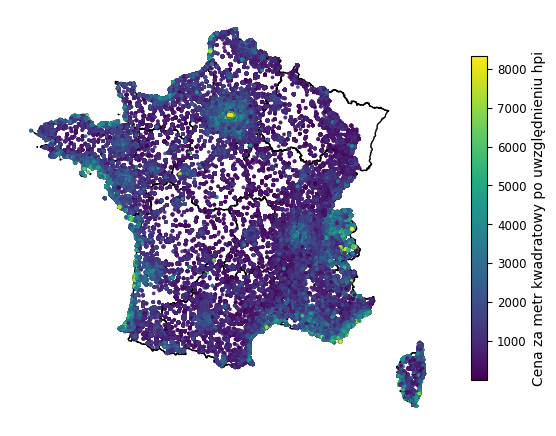

In [9]:
map = gpd.read_file(france_regions_map_url)

points = gpd.GeoDataFrame(sample,geometry=gpd.points_from_xy(sample.longitude, sample.latitude),crs="EPSG:4326")
points = points[points["price_m_2_adj"].notna()]

low = points["price_m_2_adj"].quantile(0.05)
high = points["price_m_2_adj"].quantile(0.95)

points = points[(points["price_m_2_adj"] >= 0) & (points["price_m_2_adj"] <= high)]

fig, ax = plt.subplots(figsize=(7, 7))
map.plot(ax=ax, facecolor="white", edgecolor="black")
points.plot(ax=ax, column="price_m_2_adj", cmap="viridis", markersize= 3, alpha=0.8, legend=True, legend_kwds={"shrink": 0.6, "label": "Cena za metr kwadratowy po uwzględnieniu hpi"})

ax.set_axis_off()
plt.show()

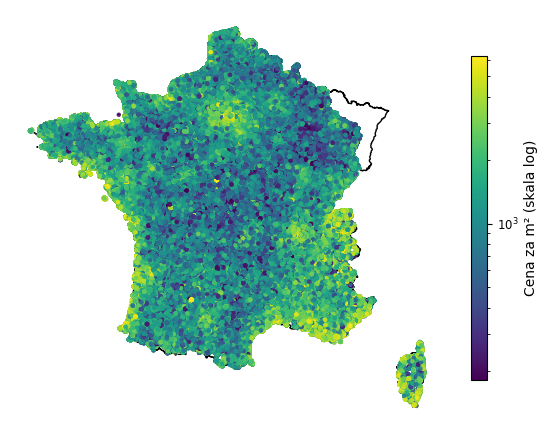

In [10]:

map = gpd.read_file(france_regions_map_url)

points = gpd.GeoDataFrame(sample,geometry=gpd.points_from_xy(sample.longitude, sample.latitude),crs="EPSG:4326")
points = points[points["price_m_2_adj"].notna()]

low = points["price_m_2_adj"].quantile(0.02)
high = points["price_m_2_adj"].quantile(0.98)
points = points[(points["price_m_2_adj"] >= low) & (points["price_m_2_adj"] <= high)]


fig, ax = plt.subplots(figsize=(7, 7))
map.plot(ax=ax, facecolor="white", edgecolor="black")
norm = colors.LogNorm(vmin=points["price_m_2_adj"].min(), vmax=points["price_m_2_adj"].max())
points.plot(ax=ax, column="price_m_2_adj", cmap="viridis", markersize=5, alpha=0.8, legend=True, norm=norm, legend_kwds={"shrink": 0.6, "label": "Cena za m² (skala log)"})

ax.set_axis_off()
plt.show()

In [ ]:
# PRZYKŁAD: zależność ceny za metr kwadratowy od lokalizacji w rejonie paryskim #


sample_paris = sample[sample["department_code"].isin(["75", "92", "93", "94"])].copy()
sample_paris = sample_paris.dropna(subset=["latitude", "longitude", "price_m_2_adj"])

low, high = sample_paris["price_m_2_adj"].quantile([0.05, 0.99])
sample_paris = sample_paris[sample_paris["price_m_2_adj"] <= high].sample(30000)

points_paris = gpd.GeoDataFrame(sample_paris, geometry=gpd.points_from_xy(sample_paris.longitude, sample_paris.latitude), crs="EPSG:4326")

paris_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
paris_map = gpd.read_file(paris_url).to_crs("EPSG:4326")
paris_shape = paris_map[paris_map["code"] == "75056"]


center = [points_paris.geometry.y.mean(), points_paris.geometry.x.mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

folium.GeoJson(paris_shape.__geo_interface__, name="Obrys Paryża", style_function=lambda x: {"color": "black", "weight": 2, "fillOpacity": 0}).add_to(m)

vmin = float(points_paris["price_m_2_adj"].quantile(0.05))
vmax = float(points_paris["price_m_2_adj"].quantile(0.95))

cmap = linear.YlOrRd_09.scale(vmin, vmax)
cmap.caption = "Cena / m² (adj)"


for r in points_paris.itertuples(index=False):
    val = float(r.price_m_2_adj)
    col = cmap(val)

    folium.CircleMarker(location=[r.latitude, r.longitude], radius=3, color=col, fill=True, fill_color=col, fill_opacity=0.75, weight=0).add_to(m)

cmap.add_to(m)
folium.LayerControl(collapsed=True).add_to(m)

out_html = "paris_prices.html"
m.save(out_html)
